# Convolucion de Matrices e Imagenes: Padding y Stride

Implementar la operacion de convolucion manualmente con NumPy
y demostrar el efecto de padding y stride sobre los mapas de caracteristicas, misma imagen, mismo kernel, solo varia padding o stride.

---

## 0. Importaciones

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

print("Librerias cargadas.")

Librerias cargadas.


## 1. convolucion

La convolucion aplica un filtro (kernel) sobre una imagen para producir un mapa de caracteristicas, el kernel se desliza por la entrada y en cada posicion calcula el producto punto entre sus valores y los valores de la region correspondiente de la entrada.

**Formula del tamano de salida:**
```
H_out = floor((H_in + 2*padding - kernel_size) / stride) + 1
W_out = floor((W_in + 2*padding - kernel_size) / stride) + 1
```

### Que cambia con padding y stride

**Padding** Agrega filas/columnas de ceros alrededor de la entrada,controla el tamaño de salida y preservacion de bordes

**Stride** Paso con el que el kernel se desplaza, stride mayor produce mapas mas pequeños y reduce resolucion


## 2. Implementacion manual de convolucion (NumPy)

In [3]:
def convolucionar(entrada, kernel, padding=0, stride=1):
    """
    Convolucion 2D manual sobre una matriz 2D.

    Parametros:
        entrada  : numpy array 2D (H_in x W_in)
        kernel   : numpy array 2D (kH x kW)
        padding  : int, filas/columnas de ceros que se agregan alrededor
        stride   : int, paso de desplazamiento del kernel

    Retorna:
        mapa de caracteristicas (feature map) como numpy array 2D
    """
    H_in, W_in = entrada.shape
    kH, kW = kernel.shape

    # Aplicar padding: rodear la entrada con ceros
    if padding > 0:
        entrada = np.pad(entrada, padding, mode="constant", constant_values=0)

    # Calcular dimensiones del mapa de salida
    H_out = (H_in + 2 * padding - kH) // stride + 1
    W_out = (W_in + 2 * padding - kW) // stride + 1

    salida = np.zeros((H_out, W_out))

    # Deslizar el kernel sobre la entrada
    for i in range(H_out):
        for j in range(W_out):
            # Region de la entrada que el kernel cubre en este paso
            region = entrada[i*stride : i*stride + kH,
                             j*stride : j*stride + kW]
            # Producto punto: suma de productos elemento a elemento
            salida[i, j] = np.sum(region * kernel)

    return salida

print("Funcion convolucionar() definida.")

Funcion convolucionar() definida.


## 3. Ejemplo con matriz numerica 6x6

Verificacion del algoritmo sobre valores conocidos antes de aplicar en imagenes.

In [4]:
entrada = np.array([
    [1, 2, 3, 4, 5, 6],
    [7, 8, 9,10,11,12],
    [1, 3, 5, 7, 9,11],
    [2, 4, 6, 8,10,12],
    [0, 1, 2, 3, 4, 5],
    [6, 7, 8, 9,10,11]
], dtype=float)

# Kernel Sobel horizontal: detecta bordes horizontales
kernel = np.array([[-1,-2,-1],[0,0,0],[1,2,1]], dtype=float)

print(f"Entrada: {entrada.shape}  Kernel: {kernel.shape}")
print()

# padding=0, stride=1 (base)
r1 = convolucionar(entrada, kernel, padding=0, stride=1)
print(f"[padding=0, stride=1] salida: {r1.shape}")
print(np.round(r1, 1))
print()

# padding=1, stride=1 (preserva dimensiones)
r2 = convolucionar(entrada, kernel, padding=1, stride=1)
print(f"[padding=1, stride=1] salida: {r2.shape}")
print(np.round(r2, 1))
print()

# padding=0, stride=2 (subsampleo)
r3 = convolucionar(entrada, kernel, padding=0, stride=2)
print(f"[padding=0, stride=2] salida: {r3.shape}")
print(np.round(r3, 1))

Entrada: (6, 6)  Kernel: (3, 3)

[padding=0, stride=1] salida: (4, 4)
[[  4.   8.  12.  16.]
 [-16. -12.  -8.  -4.]
 [ -8. -12. -16. -20.]
 [ 12.   8.   4.   0.]]

[padding=1, stride=1] salida: (6, 6)
[[ 22.  32.  36.  40.  44.  35.]
 [  1.   4.   8.  12.  16.  14.]
 [-14. -16. -12.  -8.  -4.  -1.]
 [ -4.  -8. -12. -16. -20. -17.]
 [ 11.  12.   8.   4.   0.  -2.]
 [ -1.  -4.  -8. -12. -16. -14.]]

[padding=0, stride=2] salida: (2, 2)
[[  4.  12.]
 [ -8. -16.]]


## 4. Convolucion sobre imagen sintetica

Se aplica el mismo kernel Sobel horizontal variando unicamente padding o stride.

In [5]:
np.random.seed(42)
imagen = np.zeros((32, 32), dtype=float)
imagen[8:24, 8:24] = 200    # cuadrado central
imagen[14:18, :] = 150      # franja horizontal
imagen[:, 14:18] = 150      # franja vertical
imagen += np.random.randn(32, 32) * 5
imagen = np.clip(imagen, 0, 255)

# Kernel base: el mismo en todas las comparaciones
kernel_base = np.array([[-1,-2,-1],[0,0,0],[1,2,1]], dtype=float)

print(f"Imagen entrada: {imagen.shape}")
print(f"Kernel base (Sobel horizontal):\n{kernel_base}")

Imagen entrada: (32, 32)
Kernel base (Sobel horizontal):
[[-1. -2. -1.]
 [ 0.  0.  0.]
 [ 1.  2.  1.]]


## 5. Efecto del Padding (stride=1 fijo)

- `padding=0`: salida mas pequena (bordes descartados)
- `padding=1`: salida igual que entrada (dimensiones preservadas)
- `padding=2`: salida mas grande que la entrada

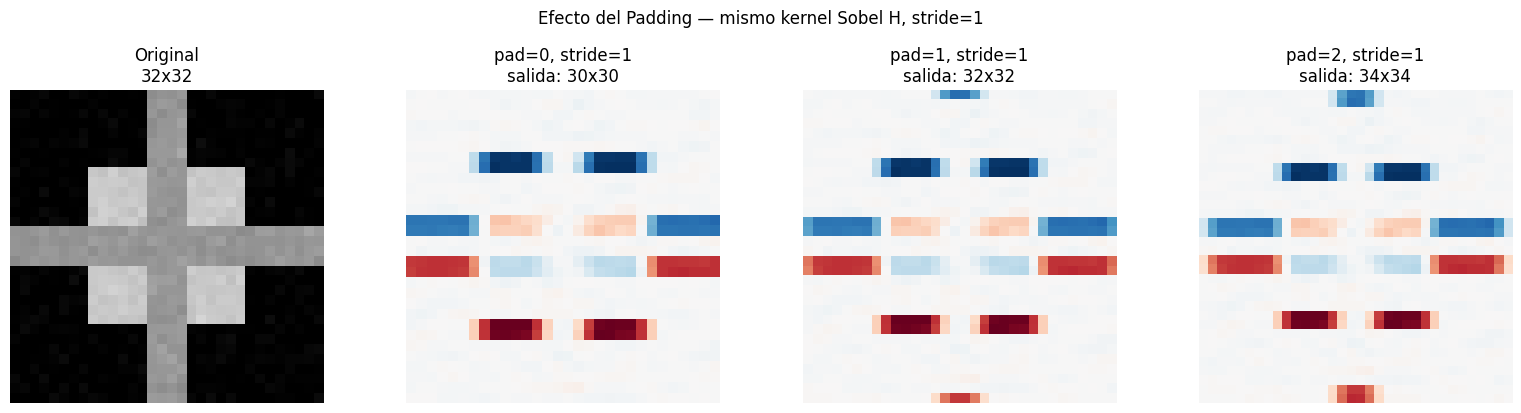


Tabla dimensiones — Padding (stride=1):
  Config                 Entrada    Salida     % area
  pad=0, stride=1        (32, 32)   (30, 30)   87.9%
  pad=1, stride=1        (32, 32)   (32, 32)   100.0%
  pad=2, stride=1        (32, 32)   (34, 34)   112.9%


In [6]:
pad_configs = [
    {"label": "pad=0, stride=1", "padding": 0, "stride": 1},
    {"label": "pad=1, stride=1", "padding": 1, "stride": 1},
    {"label": "pad=2, stride=1", "padding": 2, "stride": 1},
]

# Aplicar convolucion para cada configuracion de padding
pad_fms = [convolucionar(imagen, kernel_base, cfg["padding"], cfg["stride"]) for cfg in pad_configs]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# Columna 0: imagen original como referencia
axes[0].imshow(imagen, cmap="gray", vmin=0, vmax=255)
axes[0].set_title(f"Original\n{imagen.shape[0]}x{imagen.shape[1]}")
axes[0].axis("off")

# Columnas 1-3: feature maps con padding creciente (stride=1 fijo)
# RdBu: rojo = activacion positiva (borde ascendente), azul = negativa (borde descendente)
for ax, cfg, fm in zip(axes[1:], pad_configs, pad_fms):
    ax.imshow(fm, cmap="RdBu", interpolation="nearest")
    ax.set_title(f"{cfg['label']}\nsalida: {fm.shape[0]}x{fm.shape[1]}")
    ax.axis("off")

plt.suptitle("Efecto del Padding — mismo kernel Sobel H, stride=1", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# Tabla de dimensiones: muestra cuanto crece o encoge la salida segun el padding
print("\nTabla dimensiones — Padding (stride=1):")
print(f"  {'Config':<22} {'Entrada':<10} {'Salida':<10} % area")
for cfg, fm in zip(pad_configs, pad_fms):
    pct = round(100 * fm.shape[0] * fm.shape[1] / (imagen.shape[0] * imagen.shape[1]), 1)
    print(f"  {cfg['label']:<22} {str(imagen.shape):<10} {str(fm.shape):<10} {pct}%")

## 6. Efecto del Stride (padding=0 fijo)

- `stride=1`: mapa de alta resolucion
- `stride=2`: mapa reducido a la mitad aprox.
- `stride=3`: mapa muy comprimido, pierde detalle espacial

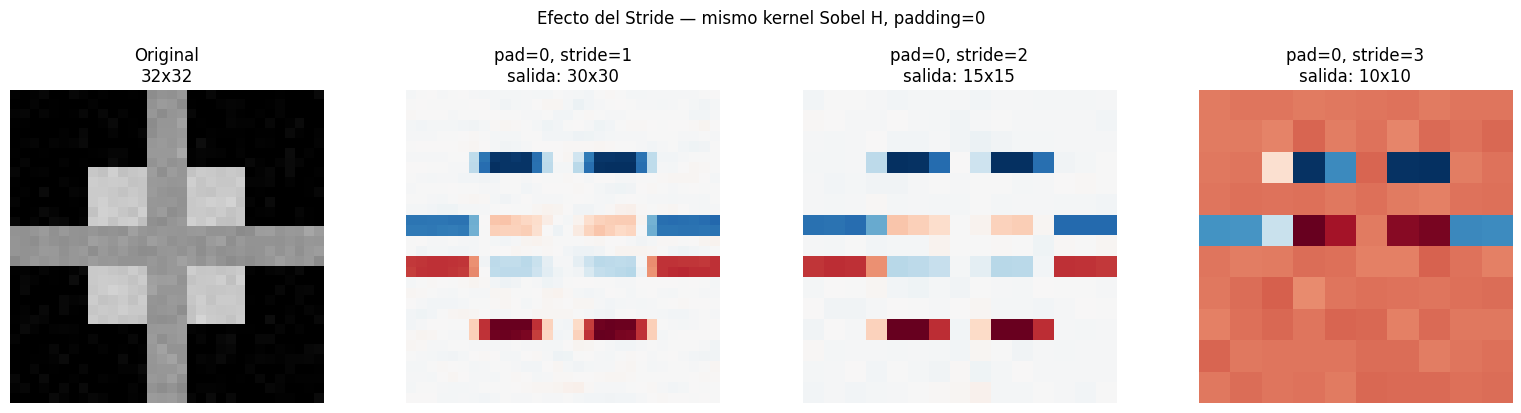


Tabla dimensiones — Stride (padding=0):
  Config                 Entrada    Salida     % area
  pad=0, stride=1        (32, 32)   (30, 30)   87.9%
  pad=0, stride=2        (32, 32)   (15, 15)   22.0%
  pad=0, stride=3        (32, 32)   (10, 10)   9.8%


In [7]:
stride_configs = [
    {"label": "pad=0, stride=1", "padding": 0, "stride": 1},
    {"label": "pad=0, stride=2", "padding": 0, "stride": 2},
    {"label": "pad=0, stride=3", "padding": 0, "stride": 3},
]

# Aplicar convolucion para cada configuracion de stride
stride_fms = [convolucionar(imagen, kernel_base, cfg["padding"], cfg["stride"]) for cfg in stride_configs]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# Columna 0: imagen original como referencia
axes[0].imshow(imagen, cmap="gray", vmin=0, vmax=255)
axes[0].set_title(f"Original\n{imagen.shape[0]}x{imagen.shape[1]}")
axes[0].axis("off")

# Columnas 1-3: feature maps con stride creciente (padding=0 fijo)
# A mayor stride, menor resolucion espacial: los bordes se ven mas difusos/pixelados
for ax, cfg, fm in zip(axes[1:], stride_configs, stride_fms):
    ax.imshow(fm, cmap="RdBu", interpolation="nearest")
    ax.set_title(f"{cfg['label']}\nsalida: {fm.shape[0]}x{fm.shape[1]}")
    ax.axis("off")

plt.suptitle("Efecto del Stride — mismo kernel Sobel H, padding=0", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# Tabla de dimensiones: muestra la reduccion de area segun el stride
print("\nTabla dimensiones — Stride (padding=0):")
print(f"  {'Config':<22} {'Entrada':<10} {'Salida':<10} % area")
for cfg, fm in zip(stride_configs, stride_fms):
    pct = round(100 * fm.shape[0] * fm.shape[1] / (imagen.shape[0] * imagen.shape[1]), 1)
    print(f"  {cfg['label']:<22} {str(imagen.shape):<10} {str(fm.shape):<10} {pct}%")

## 7. Comparacion de kernels (padding=1, stride=1)

Con las mismas condiciones de padding y stride, el disenio del kernel determina
que caracteristicas se extraen del mapa de salida.

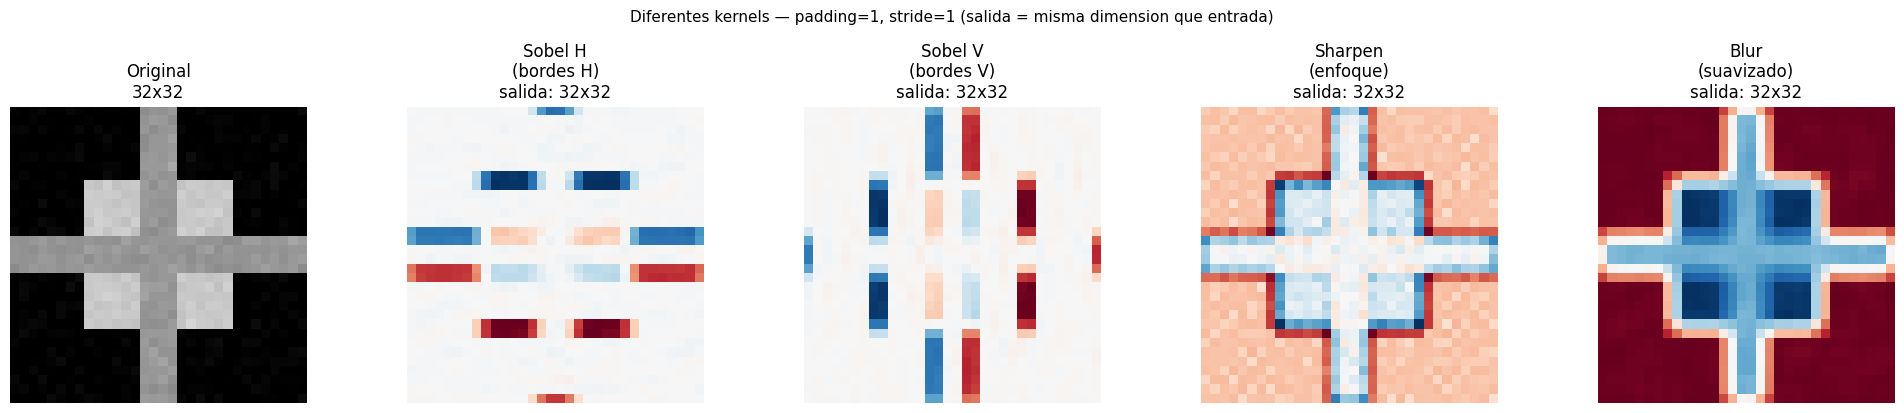

In [8]:
kernels_dict = {
    "Sobel H\n(bordes H)": np.array([[-1,-2,-1],[0,0,0],[1,2,1]], dtype=float),
    "Sobel V\n(bordes V)": np.array([[-1,0,1],[-2,0,2],[-1,0,1]], dtype=float),
    "Sharpen\n(enfoque)":  np.array([[0,-1,0],[-1,5,-1],[0,-1,0]], dtype=float),
    "Blur\n(suavizado)":   np.ones((3,3), dtype=float) / 9,
}

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

# Columna 0: imagen original como referencia
axes[0].imshow(imagen, cmap="gray", vmin=0, vmax=255)
axes[0].set_title(f"Original\n{imagen.shape[0]}x{imagen.shape[1]}")
axes[0].axis("off")

# Columnas 1-4: cada kernel produce un tipo diferente de feature map
# padding=1, stride=1 en todos: las dimensiones de salida son identicas a la entrada
for ax, (nombre, k) in zip(axes[1:], kernels_dict.items()):
    fm = convolucionar(imagen, k, padding=1, stride=1)
    # Visualizar el feature map resultante
    ax.imshow(fm, cmap="RdBu", interpolation="nearest")
    ax.set_title(f"{nombre}\nsalida: {fm.shape[0]}x{fm.shape[1]}")
    ax.axis("off")

plt.suptitle("Diferentes kernels — padding=1, stride=1 (salida = misma dimension que entrada)",
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

## 8. Tabla resumen global

In [9]:
todas_configs = [
    {"label": "Base pad=0, stride=1",  "padding": 0, "stride": 1},
    {"label": "Padding=1, stride=1",   "padding": 1, "stride": 1},
    {"label": "Padding=2, stride=1",   "padding": 2, "stride": 1},
    {"label": "Padding=0, stride=2",   "padding": 0, "stride": 2},
    {"label": "Padding=0, stride=3",   "padding": 0, "stride": 3},
]

H_in, W_in = imagen.shape
kH, kW = kernel_base.shape
filas = []
for cfg in todas_configs:
    fm = convolucionar(imagen, kernel_base, cfg["padding"], cfg["stride"])
    H_out, W_out = fm.shape
    filas.append({
        "Configuracion":     cfg["label"],
        "Padding":           cfg["padding"],
        "Stride":            cfg["stride"],
        "Entrada":           f"{H_in}x{W_in}",
        "Salida":            f"{H_out}x{W_out}",
        "Pct area":          f"{round(100 * H_out * W_out / (H_in * W_in), 1)}%",
    })

tabla = pd.DataFrame(filas)
print(tabla.to_string(index=False))

       Configuracion  Padding  Stride Entrada Salida Pct area
Base pad=0, stride=1        0       1   32x32  30x30    87.9%
 Padding=1, stride=1        1       1   32x32  32x32   100.0%
 Padding=2, stride=1        2       1   32x32  34x34   112.9%
 Padding=0, stride=2        0       2   32x32  15x15    22.0%
 Padding=0, stride=3        0       3   32x32  10x10     9.8%


---
## 9. Conclusiones

**1. Padding controla la preservacion de informacion en los bordes**
Sin padding (`padding=0`), el mapa de salida es mas pequeno que la entrada: con kernel 3x3
y stride=1 sobre una imagen 32x32 se obtiene 30x30 (se pierde el 12% del area).
Con `padding=1` la salida iguala la entrada (32x32), y con `padding=2` crece a 34x34.
El padding "same" es el mas usado en redes convolucionales profundas porque permite
apilar capas sin reducir dimensiones espaciales.

**2. Stride reduce la resolucion espacial**
Un stride mayor comprime el mapa de salida: `stride=2` reduce de 32x32 a 15x15 (22% del area),
y `stride=3` a 10x10 (menos del 10%). Esto es equivalente a hacer pooling: reduce costo
computacional y crea invarianza espacial, pero a costa de perder detalle fino.

**3. El diseño del kernel determina que se detecta**
Con padding=1 y stride=1 identicos, el Sobel horizontal detecta cambios en el eje Y,
el Sobel vertical en el eje X, el filtro Sharpen amplifica bordes y el Blur los suaviza.
Los pesos del kernel son los parametros que determinan que informacion se extrae;
padding y stride son parametros de diseno de la red que controlan resolucion y cobertura.